The dataset is being loaded . Spotify streaming history data registry.
Loading is successfull . The dataset is detected 149860
Extracting metrics and transformig time properties
Setting up the graphical interface for our survey on your top teir artists


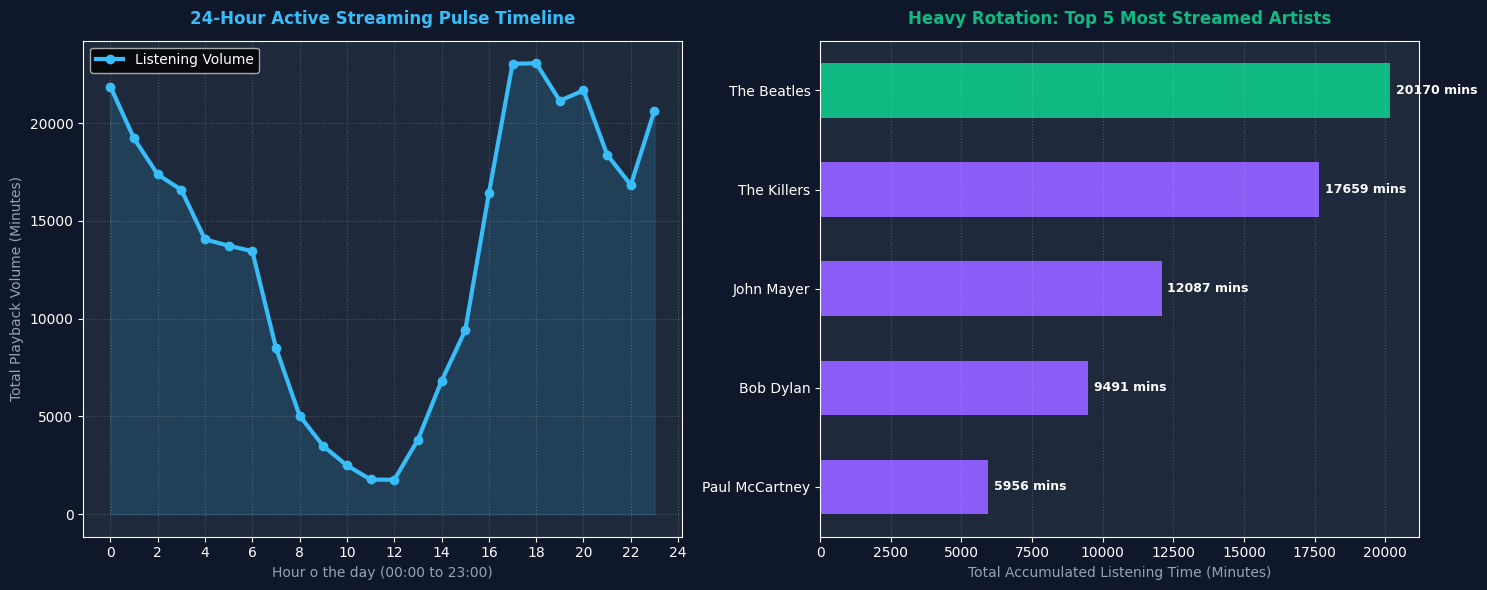

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("The dataset is being loaded . Spotify streaming history data registry.")

csv_path= r"C:\Users\adity\Downloads\Real Spotify History\spotify_history.csv"
df=pd.read_csv(csv_path)

print(f"Loading is successfull . The dataset is detected {len(df)}")

print("Extracting metrics and transformig time properties")

#converting the "ts " column from text timestamp to the padas readable timestamp 
df["ts"]=pd.to_datetime(df["ts"])

#now extracting the hour part from the converted timestamp
df["Hours_of_Day"]=df["ts"].dt.hour

# extracting the minutes part 
df["Minutes_Played"]=df["ms_played"]/60000

#now grouping the top teir profile o users 
artist_ranking=df.groupby("artist_name")["Minutes_Played"].sum().reset_index()
top_five_artists=artist_ranking.sort_values(by="Minutes_Played",ascending=True).tail(5)
hourly_trend = df.groupby("Hours_of_Day")["Minutes_Played"].sum().reset_index()

print("Setting up the graphical interface for our survey on your top teir artists")

plt.style.use("dark_background")
fig,axes=plt.subplots(1,2,figsize=(15,6)) 
fig.patch.set_facecolor("#0f172a") 

ax1=axes[0]
ax1.set_facecolor("#1e293b")

# FIXED: Aligned "Hour_of_Day" columns to match your "Hours_of_Day" initialization key
ax1.plot(hourly_trend["Hours_of_Day"],hourly_trend["Minutes_Played"],color='#38bdf8',marker='o', linewidth=3, markersize=6, label='Listening Volume')

ax1.fill_between(hourly_trend["Hours_of_Day"],hourly_trend["Minutes_Played"],color = "#38bdf8", alpha=0.15)

ax1.set_title("24-Hour Active Streaming Pulse Timeline" ,fontsize=12, fontweight="bold",color="#38bdf8"
,pad=12)

ax1.set_xlabel("Hour o the day (00:00 to 23:00)" ,color="#94a3b8")
ax1.set_ylabel("Total Playback Volume (Minutes)", color="#94a3b8")
ax1.set_xticks(np.arange(0, 25, 2)) # Slicing x-axis marks cleanly for every alternate hour block
ax1.grid(True,linestyle = ":" , alpha=0.2) # FIXED: Removed space character inside " :" string pattern
ax1.legend(loc="upper left")

ax2 = axes[1]
ax2.set_facecolor("#1e293b")

artists = top_five_artists['artist_name']
minutes = top_five_artists['Minutes_Played']

max_minutes = minutes.max()
bar_colors = ['#10b981' if m == max_minutes else '#8b5cf6' for m in minutes]

ax2.barh(artists, minutes, color = bar_colors, height=0.55, edgecolor='none')

ax2.set_title('Heavy Rotation: Top 5 Most Streamed Artists', fontsize=12, fontweight='bold', color='#10b981', pad=12)
ax2.set_xlabel('Total Accumulated Listening Time (Minutes)', color='#94a3b8')
ax2.grid(axis='x', linestyle = ':', alpha=0.2)

for idx, num in enumerate(minutes):
    ax2.text(num + (minutes.max() * 0.01), idx, f"{num:.0f} mins", va='center', color='white', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()